# 模型反演攻击 (Model Inversion Attack)

本 Notebook 演示**模型反演攻击**：攻击者通过优化输入图像，使目标模型对某个类别的输出置信度最大化，从而重建该类别在训练数据中的代表性图像。

- 核心思想：Fredrikson et al. (2015) 通过梯度上升发现，神经网络的内部表示会泄露训练样本的敏感特征。
- 参考：CAISP《模块二 技术基础篇》第 64-65 页。


In [1]:
# 导入依赖库
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [2]:
# 加载完整 CIFAR-10 数据集
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform)

CIFAR10_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
BATCH_SIZE = 64
EPOCHS = 15

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)
print(f"Train: {len(train_set)}, Test: {len(test_set)}")


Train: 50000, Test: 10000


In [3]:
# 定义 CIFAR-10 分类模型
class SimpleCNN(nn.Module):
    '''10 类 CIFAR-10 分类器'''
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


In [4]:
# 训练与评估工具函数

def train_model(model, loader, epochs=15, lr=0.001):
    '''训练目标模型'''
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
        avg_loss = running_loss / len(loader.dataset)
        print(f"Epoch {epoch+1}/{epochs}, loss: {avg_loss:.4f}")
    return model


def evaluate(model, loader):
    '''评估模型准确率'''
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total if total > 0 else 0.0


In [5]:
# 训练目标模型（约 15 个 epoch）
target_model = SimpleCNN(num_classes=10).to(device)
target_model = train_model(target_model, train_loader, epochs=EPOCHS)

test_acc = evaluate(target_model, test_loader)
print(f"Target model test accuracy: {test_acc:.4f}")


Epoch 1/15, loss: 1.5768
Epoch 2/15, loss: 1.2570
Epoch 3/15, loss: 1.1111
Epoch 4/15, loss: 1.0125
Epoch 5/15, loss: 0.9363
Epoch 6/15, loss: 0.8782
Epoch 7/15, loss: 0.8262
Epoch 8/15, loss: 0.7861
Epoch 9/15, loss: 0.7521
Epoch 10/15, loss: 0.7156
Epoch 11/15, loss: 0.6824
Epoch 12/15, loss: 0.6479
Epoch 13/15, loss: 0.6184
Epoch 14/15, loss: 0.5899
Epoch 15/15, loss: 0.5613
Target model test accuracy: 0.6927


In [6]:
# 模型反演核心：Total Variation 正则化 + 梯度上升最大化目标 logit

def total_variation(x):
    '''Total Variation 正则化，鼓励生成的图像更平滑自然'''
    dx = torch.abs(x[:, :, :, :-1] - x[:, :, :, 1:])
    dy = torch.abs(x[:, :, :-1, :] - x[:, :, 1:, :])
    return torch.mean(dx) + torch.mean(dy)


def model_inversion(model, target_class, steps=1000, lr=0.05, tv_weight=1e-2):
    '''
    对指定类别进行模型反演：
    - 从随机噪声初始化图像 x
    - 通过梯度上升最大化目标类别的 logit
    - 使用 TV 正则化抑制高频噪声
    - 每次迭代后将像素裁剪到 [0, 1]
    '''
    model.eval()
    x = torch.rand(1, 3, 32, 32).to(device).requires_grad_(True)
    optimizer = optim.Adam([x], lr=lr)

    for step in range(steps):
        optimizer.zero_grad()
        logits = model(x)
        # 最大化目标类别 logit，等价于最小化其负值
        loss = -logits[0, target_class] + tv_weight * total_variation(x)
        loss.backward()
        optimizer.step()
        # 保持有效图像范围
        with torch.no_grad():
            x.clamp_(0, 1)

    return x.detach().cpu()


Finished inversion for class 0: airplane
Finished inversion for class 1: automobile
Finished inversion for class 2: bird
Finished inversion for class 3: cat
Finished inversion for class 4: deer
Finished inversion for class 5: dog
Finished inversion for class 6: frog
Finished inversion for class 7: horse
Finished inversion for class 8: ship
Finished inversion for class 9: truck


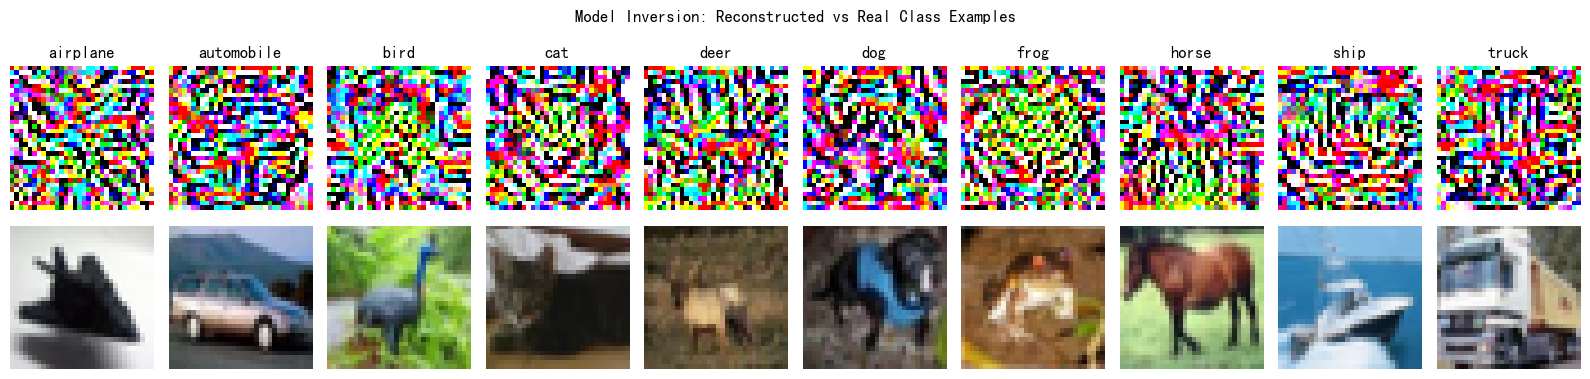

In [7]:
# 对所有 10 个类别执行模型反演，并可视化重建图像与真实训练样本
inverted_images = []
for c in range(10):
    img = model_inversion(target_model, c, steps=1000, lr=0.05, tv_weight=1e-2)
    inverted_images.append(img)
    print(f"Finished inversion for class {c}: {CIFAR10_NAMES[c]}")

# 从训练集中为每个类别取一张真实图像
real_examples = []
for c in range(10):
    for i in range(len(train_set)):
        if train_set[i][1] == c:
            real_examples.append(train_set[i][0])
            break

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for c in range(10):
    inv = inverted_images[c].squeeze(0).permute(1, 2, 0).numpy()
    real = real_examples[c].permute(1, 2, 0).numpy()
    axes[0, c].imshow(np.clip(inv, 0, 1))
    axes[0, c].set_title(CIFAR10_NAMES[c])
    axes[0, c].axis('off')
    axes[1, c].imshow(np.clip(real, 0, 1))
    axes[1, c].axis('off')
axes[0, 0].set_ylabel('Inverted', rotation=0, labelpad=25)
axes[1, 0].set_ylabel('Real', rotation=0, labelpad=25)
plt.suptitle('Model Inversion: Reconstructed vs Real Class Examples')
plt.tight_layout()
plt.show()


Epoch 1/3, loss: 1.5552
Epoch 2/3, loss: 1.2249
Epoch 3/3, loss: 1.0791


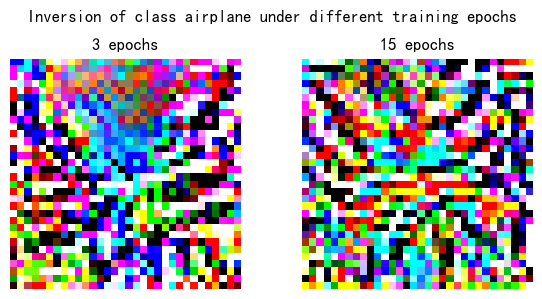

In [8]:
# 训练不同 epoch 的模型，观察过拟合程度对反演质量的影响
# 理论上，模型越“记住”训练数据，反演图像越接近真实训练样本

model_3epoch = SimpleCNN(num_classes=10).to(device)
model_3epoch = train_model(model_3epoch, train_loader, epochs=3)

model_15epoch = target_model  # 已训练 15 epoch

target_class = 0  # 选择 airplane 类别进行可视化
inv_3 = model_inversion(model_3epoch, target_class, steps=1000, lr=0.05, tv_weight=1e-2)
inv_15 = model_inversion(model_15epoch, target_class, steps=1000, lr=0.05, tv_weight=1e-2)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(np.clip(inv_3.squeeze(0).permute(1, 2, 0).numpy(), 0, 1))
axes[0].set_title('3 epochs')
axes[0].axis('off')
axes[1].imshow(np.clip(inv_15.squeeze(0).permute(1, 2, 0).numpy(), 0, 1))
axes[1].set_title('15 epochs')
axes[1].axis('off')
plt.suptitle(f'Inversion of class {CIFAR10_NAMES[target_class]} under different training epochs')
plt.tight_layout()
plt.show()


**可视化：真实图像 vs 重构图像**

对比 CIFAR-10 每个类别的真实训练样本与模型反演得到的最具代表性图像。

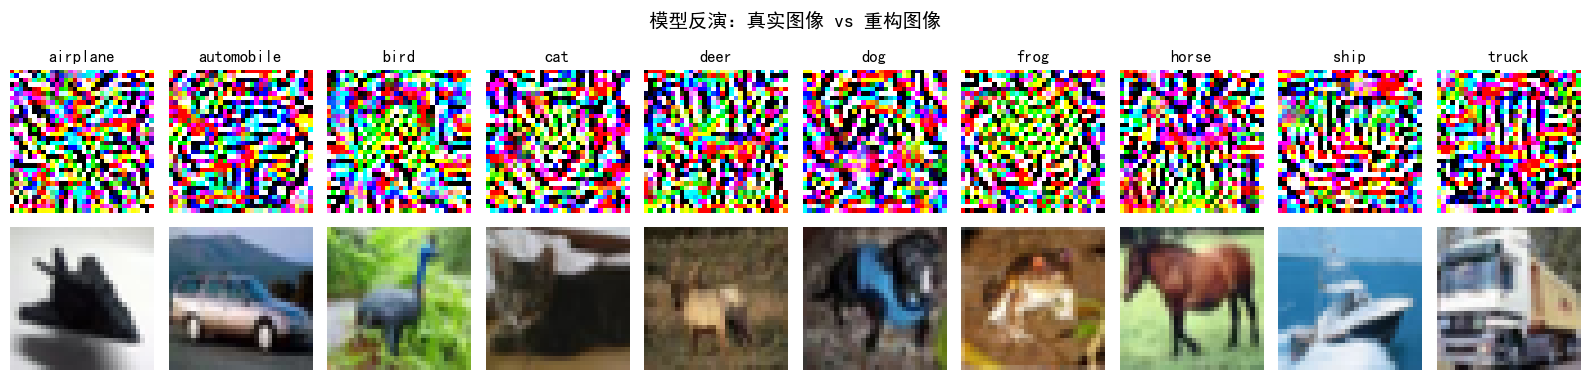

In [9]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for c in range(10):
    inv = inverted_images[c].squeeze(0).permute(1, 2, 0).numpy()
    real = real_examples[c].permute(1, 2, 0).numpy()

    axes[0, c].imshow(np.clip(inv, 0, 1))
    axes[0, c].set_title(CIFAR10_NAMES[c])
    axes[0, c].axis('off')

    axes[1, c].imshow(np.clip(real, 0, 1))
    axes[1, c].axis('off')

axes[0, 0].set_ylabel('Inverted', rotation=0, labelpad=25)
axes[1, 0].set_ylabel('Real', rotation=0, labelpad=25)
plt.suptitle('模型反演：真实图像 vs 重构图像', fontsize=14)
plt.tight_layout()
plt.show()


## 小结与防御思路

- **攻击原理**：模型反演攻击通过梯度上升优化一个随机输入，使其在目标类别上的置信度最大。如果模型对训练数据过拟合，重建图像往往会泄露训练样本的统计特征。
- **防御方法**：
  1. **差分隐私训练**：限制模型对单个训练样本的依赖，降低反演质量。
  2. **输出压缩**：只输出 top-1 标签或低精度概率，减少攻击者可利用的梯度信息。
  3. **查询/梯度访问控制**：避免暴露完整模型或 logits，限制模型反演所需的梯度/预测信息。
